# **Evidencia 4. Análisis de Aprendizaje Automático**

**Analítica de datos y herramientas de inteligencia artificial (Gpo 601)**

- Jorge Emiliano Gómez Hernández | A01368016
- Jaime Trujillo Ruiz | A01276139
- Lisy León Rubio | A01369783
- Montserrat Hernández Pérez | A01276367


## **Sección 1: Contexto y Vinculación con Evidencia 3**

---
---





### 1.1 Resumen del problema CNH.

Como ya se ha mencionado, CNH México es una empresa que comercializa maquinaria agrícola y de construcción bajo las marcas New Holland Agriculture, New Holland Construction, Case IH y Case CE, entre otras. Su área de after-market genera ingresos a través de los servicios de mantenimiento preventivo que las unidades vendidas deben realizar de forma periódica, conforme a intervalos definidos por horas de operación acumulada: 50, 300, 600, 900, 1,200, 1,500, 1,800, 2,100 y 2,400 horas.



El flujo de valor del área:

**Uso → Desgaste → Servicio de Mantenimiento → Ingreso**

El cliente opera su unidad, acumula horas, el distribuidor detecta la necesidad de servicio a través de los datos telemétricos y las alertas, y contacta al cliente para que lleve su unidad a mantenimiento. Si el cliente lo lleva, se genera un ingreso para CNH. Si no lo lleva, o lo lleva a un taller externo, ese ingreso se pierde.

El problema central identificado es que hoy el área opera de forma **reactiva**: el incumplimiento se detecta cuando ya ocurrió. El estatus "CerradaFuera" indica que la unidad realizó el servicio fuera de la red CNH y el estatus "Pendiente" indica que el servicio no se ha realizado o no se cuenta con la información de qué manera fue realizado el servicio.

Después de nuestro análisis hemos llegado a que en ambos casos representan una falla en la cadena de valor que, en el análisis exploratorio de la Evidencia 3, se observó de forma sistemática a partir del intervalo de 600 horas, que es precisamente donde la proporción de unidades con estatus "CerradaFuera" y "Pendiente" supera por primera vez a las unidades con estatus "Cerrada" (cumplidas dentro de la red CNH).




**Otros hallazgos de las evidencias anteriores que nos ayudan a contextualizar la situación que se presenta en el área aftermarket:**

- **El intervalo de 600 h es el punto de quiebre de la fidelización**, confirmado en la Actividad 2 mediante regresión logística (OR significativo, R2 = 0.3618): incumplir por primera vez en ese intervalo multiplica la probabilidad de no regresar a los siguientes servicios dentro de la red.
- **El incumplimiento no es uniforme entre distribuidores ni entre zonas geográficas**: la Actividad 2 nos confirmó diferencias estadísticamente significativas tanto por distribuidor (ANOVA) como por zona geográfica, lo que indica que el problema tiene causas estructurales, no son aleatorias.
- **El tiempo entre la generación de la alarma de servicio y su realización tiene una moda de 0 días a nivel global**, pero hay distribuidores con retraso de más de 30 días sobre el promedio, lo que señala diferencias reales en la capacidad de seguimiento.

El objetivo de esta evidencia es formalizar técnicamente los modelos que permitan pasar de ese diagnóstico a un modo predictivo y prescriptivo: validar si es posible anticipar qué unidades tienen mayor riesgo de incumplimiento, estimar la demanda futura por distribuidor, e identificar el momento de contacto con mayor probabilidad de conversión por zona geográfica.

(*Conversión refiriéndose a los clientes que pasan de `CerradoFuera` (servicio con un taller externo) a `Cerrado` (servicio en red CNH)*)

### 1.2 Modelos implementados y justificación de selección

La selección de cada modelo responde directamente a la naturaleza de la pregunta estadística formalizada en la Evidencia 3. Se siguió la metodología CRISP-DM: el tipo de pregunta determina el tipo de modelo, no al revés.

| ID | Tipo | Pregunta resumida | Modelo |
|----|------|-------------------|--------|
| D1 | Descriptiva | ¿Existe un intervalo de servicio a partir del cual los clientes que incumplen una vez ya no regresan a cumplir los siguientes dentro de la red CNH? | Regresión logística |
| D2 | Descriptiva | ¿Cuál es el tiempo en "moda" entre que se genera la alarma de servicio y el momento en que efectivamente se realiza, por distribuidor? | Distribución de frecuencias + ANOVA |
| D3 | Descriptiva | ¿Hay estacionalidad en el abandono del mantenimiento? | ADF + SARIMA |
| D4 | Descriptiva | ¿Cómo se comporta el estatus de servicios por distribuidor? | ANOVA de una vía |
| DX1 | Diagnóstica | ¿Los equipos que tuvieron un servicio retrasado tienden a incumplir el siguiente, o el retraso los "resetea"? | Regresión logística |
| DX2 | Diagnóstica | ¿Qué relación tienen horómetro, c_fuera, cerrados, distancia, t_encendido_hrs y pendientes con las diferencias entre distribuidores? | Regresión lineal múltiple |
| DX3 | Diagnóstica | ¿Las unidades de ciertas zonas tienden a incumplir en el mismo intervalo? | ANOVA + Eta² |
| DX4 | Diagnóstica | ¿Las unidades con más de dos servicios consecutivos cerradas fuera regresan a la red CNH? | Regresión logística |
| P1 | Predictiva | ¿Qué tipo de unidad tiene mayor riesgo de no cumplir sus próximos servicios? | XGBoost vs. Random Forest |
| P2 | Predictiva | ¿Qué distribuidores presentarán una sobrecarga en el próximo mes? | Series de tiempo (SES) |
| Pr1 | Prescriptiva | ¿Cuál es el momento óptimo para contactar a cada cliente según su zona? | XGBoost vs. Random Forest |

---

A continuación, se presenta la justificación de cada hipótesis realizada para cada pregunta de conocimiento estadístico:


**Hipótesis Descriptivas**

**D1 — ¿Existe un punto de quiebre en la cadena de fidelización?**

Modelo: **Regresión logística**

La variable objetivo es binaria (el cliente regresa o no al siguiente servicio) y la pregunta busca estimar la probabilidad de no retorno en función del intervalo incumplido. La regresión logística permite calcular el Odds Ratio por intervalo, que es exactamente la métrica que define el punto de quiebre.


**D2 — ¿Cuál es el tiempo en "moda" entre la alarma y la realización del servicio, por distribuidor?**

Modelo: **Distribución de frecuencias + ANOVA**

La pregunta no busca una predicción sino describir la distribución del tiempo de respuesta por distribuidor. La moda es la medida de tendencia central correcta para una distribución asimétrica con pico claro. El ANOVA complementa al comparar si esas modas difieren significativamente entre distribuidores.

**D3 — ¿Hay estacionalidad real en el abandono del mantenimiento?**

Modelo: **ADF + SARIMA**

La regresión lineal simple, modelo original de esta hipótesis, no detecta estacionalidad: solo mide si hay tendencia lineal en el tiempo, que es una pregunta distinta. A partir de la retroalimentación del profesor Gustavo Santana, se incorporó SARIMA para modelar la componente estacional de la serie. La prueba ADF (Augmented Dickey-Fuller) verifica primero si la serie es estacionaria, condición necesaria para correr SARIMA de forma válida. Con 24 observaciones mensuales, la combinación ADF + SARIMA es el enfoque correcto para detectar y proyectar patrones estacionales en el abandono.

**D4 — ¿Cómo se comporta el estatus de servicios por distribuidor?**

Modelo: **ANOVA**

La pregunta compara una variable numérica continua (tasa de cumplimiento) entre más de dos grupos independientes (distribuidores). El estadístico F determina si hay diferencias reales entre grupos y el Eta² mide la magnitud de esas diferencias.

---

**Hipótesis Diagnósticas**

**DX1 — ¿Un servicio retrasado predice el siguiente incumplimiento?**

Modelo: **Regresión logística**

La variable objetivo es binaria (cumple o no el siguiente servicio) y el predictor es binario (tuvo retraso o no). El OR cuantifica el efecto del retraso sobre la probabilidad de cumplimiento futuro y permite determinar si ese efecto es protector o de riesgo.

**DX2 — ¿Qué relación tienen horómetro, c_fuera, cerrados, distancia, t_encendido_hrs y pendientes con las diferencias entre distribuidores?**

Modelo: **Regresión lineal múltiple**

La variable objetivo es numérica continua (número de servicios pendientes por distribuidor) y hay múltiples predictores telemétricos simultáneos. La regresión lineal múltiple estima la contribución individual de cada variable controlando por las demás. Las métricas de evaluación son R² ajustada y p-valor por coeficiente.

**DX3 — ¿Las unidades de ciertas zonas tienden a incumplir en el mismo intervalo?**

Modelo: **ANOVA + Eta²**

La pregunta compara la tasa de incumplimiento entre zonas geográficas SADER, que son más de dos grupos independientes. El ANOVA determina si las diferencias son estadísticamente significativas y el Eta² mide si el efecto de la zona sobre el incumplimiento es pequeño, mediano o grande, lo que tiene implicación directa en si vale la pena diseñar estrategias diferenciadas por zona.

**DX4 — ¿Las unidades con más de dos servicios "cerrada fuera" consecutivos regresan a la red CNH?**

Modelo: **Regresión logística**

La variable objetivo es binaria (regresa o no a la red CNH) y el predictor es binario (tuvo ≥ 2 servicios consecutivos fuera o no). El OR cuantifica cuánto reduce la probabilidad de retorno haber salido de la red más de una vez, lo que define si existe un punto de no retorno operativo.

---

**Hipótesis Predictivas**

**P1 — ¿Qué tipo de unidad tiene mayor riesgo de no cumplir sus próximos servicios?**

Modelo: **XGBoost vs. Random Forest (clasificación)**

La variable objetivo es binaria (tiene pendientes o no) y el espacio de features es multidimensional con posibles relaciones no lineales entre variables telemáticas. Se entrenaron ambos modelos y se seleccionó el de mayor AUC-ROC. XGBoost maneja nativamente el desbalance de clases mediante `scale_pos_weight` y su importancia de variables permite verificar si `c_fuera` es el predictor dominante, como establece la hipótesis. Score en la matriz de priorización de la Evidencia 3: **5.00 / 5.00**.


**P2 — ¿Qué distribuidores presentarán sobrecarga el próximo mes?**

Modelo: **Series de tiempo (SES)**

La pregunta requiere proyectar el volumen de alarmas del mes siguiente por distribuidor. Con 24 puntos mensuales por serie, ARIMA/SARIMA no es suficientemente estable a nivel de distribuidor individual. La SES se adapta automáticamente al nivel reciente de la serie mediante el parámetro alpha optimizado por distribuidor, sin suponer tendencia ni estacionalidad fuerte. La métrica de evaluación es el error sobre el último mes conocido.

---

**Hipótesis Prescriptiva**

**Pr1 — ¿Cuál es el momento óptimo para contactar a cada cliente según su zona?**

Modelo: **XGBoost vs. Random Forest (clasificación)**

La variable objetivo es binaria (el servicio se cumplió o no) y la interacción entre mes del año y zona geográfica genera un espacio de decisión no lineal que modelos lineales no capturan. El output del modelo — P(cumplimiento | mes, zona) — es interpretable directamente como un calendario de contacto diferenciado por región. Score en la Evidencia 3: **4.40 / 5.00**.

---



**Nota sobre los tipos de modelo:**

* Los escenarios  implementados cubren Clasificación (D1, DX1, DX4, P1, Pr1), Análisis Distribucional (D2), Series de Tiempo (D3, P2), Regresión lineal múltiple (DX2) y ANOVA (D4, DX3). No se implementó un modelo de clustering porque ninguna hipótesis  en la Evidencia 3 generó una pregunta de segmentación con variable objetivo indefinida; todas las preguntas predictivas y prescriptivas tienen variable objetivo binaria definida.

---

### 1.3 Modelos a Desarrollar

Una vez explicado esto, los modelos que se van a desarrollar en esta evidencia, son correspondientes a los insights que consideramos más relevantes y de valor para el proyecto, que fueron seleccionados en la evidencia anterior ("Evidencia 3"), por lo que se desarrollarán los siguientes modelos:


## **Modelo 1: Regresión Logística (Clasificación)** - Pregunta Descriptiva 1

* **Pregunta de conocimiento estadístico:**	¿Existe un intervalo de servicio a partir del cual los clientes que incumplen una vez, ya no regresan a cumplir los siguientes dentro de la red CNH, es decir hay un punto de quiebre en la cadena de fidelización?

* **Hipótesis:**
  * Nula (H0): La probabilidad de que un cliente regrese al siguiente servicio es la misma sin importar en qué intervalo incumplió por primera vez, el historial de incumplimiento no afecta el comportamiento futuro.

  * Alternativa (H1): Existe un intervalo específico, el de las 600 horas (mant_600h), donde incumplir multiplica por al menos 10 veces la probabilidad de no regresar al siguiente servicio dentro de la red CNH. Ese punto es el quiebre de la relación con el cliente.

* **Aplicación:** Analizar si incumplir un servicio en un intervalo predice el incumplimiento del siguiente.
---

## **Modelo 2: Regresión Logística (Clasificación)** - Pregunta Diagnóstica 4

* **Pregunta de conocimiento estadístico:** ¿Las unidades que llevan más de dos servicios consecutivos "cerradas fuera" regresan alguna vez a la red CNH, o una vez que salen ya no vuelven?

* **Hipótesis:**
  * Nula (H0): La proporción de unidades que regresan a la red CNH en los 6 meses siguientes es la misma entre las unidades que tuvieron 2 o más servicios consecutivos cerrada_fuera y las que tuvieron 0 o 1, haber salido dos veces no reduce la probabilidad de regresar.

  * Alternativa (H1): Las unidades con 2 o más servicios consecutivos cerrada_fuera regresan significativamente menos a la red CNH, con una diferencia de al menos 15 puntos porcentuales respecto al grupo de control. Ese umbral es el mínimo para que tenga sentido que CNH intervenga activamente después del primer servicio externo.

* **Aplicación:** Identificar si el segundo servicio externo actúa como punto de no retorno a la red de CNH.

---

## **Modelo 3: ANOVA** - Pregunta Diagnóstica 3

* **Pregunta de conocimiento estadístico:** ¿Las unidades de ciertas zonas del país tienden a incumplir siempre en el mismo intervalo de servicio, o el incumplimiento es aleatorio sin importar dónde estén ubicadas?

* **Hipótesis:**
  * Nula (H0): La tasa de incumplimiento de servicios es igual en todas las zonas geográficas del país (Noreste, Noroeste, Centro Occidente, Centro y Sur-Sureste), la zona donde opera una unidad no influye en si cumple o no con sus servicios.
  * Alternativa (H1): Al menos una zona geográfica presenta una tasa de cumplimiento 10 puntos porcentuales diferente al promedio nacional. Se espera que el Noreste quede por debajo del promedio, dado que sus cultivos forrajeros generan períodos de trabajo más intensivos, y que el Noroeste quede por encima, dado que el riego tecnificado de Sinaloa y Sonora tiene un calendario más estructurado.

* **Aplicación:** Identificar diferencias estadísticamente significativas en la tasa de cumplimiento de mantenimiento entre las zonas del país

---

## **Modelo 4: Series de Tiempo** - Pregunta Predictiva 2

* **Pregunta de conocimiento estadístico:** ¿Qué distribuidores presentarán una sobrecarga de unidades que necesiten servicio en el próximo mes?

* **Hipótesis:**
  * Nula (H0): La cantidad de alarmas de servicio que generará cada distribuidor en el siguiente mes no es predecible, cualquier proyección cae dentro del rango normal de variación histórica y no permite identificar distribuidores en riesgo de sobrecarga.
  * Alternativa (H1): Al menos 4 distribuidores presentarán una demanda proyectada que supera el 150% del promedio nacional, con un intervalo de confianza que confirma que ese nivel de sobrecarga no es resultado del azar. El umbral 150% (50% más alarmas de las que normalmente recibe) se calcula desde los datos como media + 1 desviación estándar de la demanda histórica por distribuidor.

* **Aplicación:** Confirmar una sobrecarga operativa proyectable, al identificar a los distribuidores que superan la demanda nacional promedio.

## **Sección 2: Preprocesamiento y Feature Engineering**

In [ ]:
!pip install scipy scikit-learn statsmodels xgboost --quiet

In [ ]:
# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.stats import f_oneway
from scipy import stats
import statsmodels.api as sm
import statistics

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score
)
from xgboost import XGBClassifier

In [ ]:
# Acceso a archivos desde drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DIR = '/content/drive/MyDrive//RETO_CNH/0_Bases de Datos/2_limpios'
os.chdir(DIR)

In [ ]:
mant = pd.read_excel('Mantenimientos_2024_2025_limpio.xlsx')
uda  = pd.read_excel('Unidades_dia_anterior_limpio.xlsx')

print(f'Mantenimientos 2024-2025 : {mant.shape[0]:,} filas  |  {mant.shape[1]} columnas')
print(f'Unidades día anterior    : {uda.shape[0]:,} filas  |  {uda.shape[1]} columnas')
print()
display(mant.head(3))
print()
display(uda.head(3))

Mantenimientos 2024-2025 : 6,775 filas  |  10 columnas
Unidades día anterior    : 10,844 filas  |  30 columnas



,alias,marca,modelo,no_serie,distribuidor,servicio,horometro,actual,fecha,estatus
0,08-P023148-TT75,NEW HOLLAND AG,TT75,T049436M-715300029,MADISA,2700,2670.0,2897,2025-04-23 09:06:00,CerradaFuera
1,222394/ MAD SUR,NEW HOLLAND AG,6610S,NH08175M-001574130,MADISA,600,567.0,750,2024-06-08 20:53:00,Pendiente
2,227978/ MAD. SUR,NEW HOLLAND AG,6610S,S35970M-8066088,MADISA,5400,5360.0,5439,2025-03-24 14:28:00,CerradaFuera


,alias,marca,modelo,fecha_alta,no_serie,distribuidor,ciudad,estado,horometro,odometro,...,mant_1800,mant_2100,mant_2400,latitud,longitud,distancia,vel_maxima_kph,vel_promedio_kph,t_encendido_hrs,t_apagado_hrs
0,08-P018766-TT75,NEW HOLLAND AG,TT75,2021-07-19,T48920M-715245417,MADISAGRAL,Hidalgo del Parral,Chihuahua,2400.98,3.44,...,NaN,NaN,NaN,26.822224,-105.803432,0.0,0,0.0,0.0,24.0
1,08-P023148-TT75,NEW HOLLAND AG,TT75,2021-07-19,T049436M-715300029,MADISAGRAL,Hidalgo del Parral,Chihuahua,2897.01,30.13,...,NaN,NaN,Pendiente,26.813479,-105.815568,0.0,0,0.0,0.0,24.0
2,155TAYLOR,NEW HOLLAND AG,7610S HERENCIA,2021-07-19,S56577M,ATC,Dolores Hidalgo Cuna de la Independencia Nacional,Guanajuato,1889.95,85.97,...,CerradaFuera,NaN,NaN,21.143644,-100.734728,0.0,0,0.0,0.0,24.0


## 2.1 Creación de variables predictoras y filtrado de datos

### **Para el Modelo 4 (Series de Tiempo para pregunta Predictiva 2)**

### Variable de abandono

- **`abandono`** (0 o 1): vale 1 si el servicio fue incumplido. Consideramos abandono cuando el estatus es `CerradaFuera` (se hizo fuera de la red CNH) o `Pendiente` (todavía no se hizo). Vale 0 si el servicio se cerró correctamente dentro de CNH.


### **Para el Modelo 3 (ANOVA)**

### Zonas geográficas

La pregunta sobre zonas del país se responde directamente con el **estado** registrado en la tabla de unidades. Hacemos un **join** entre la tabla de mantenimientos y la tabla de unidades usando el campo `alias` como llave, y así obtenemos el estado de cada unidad.

Luego agrupamos los estados en zonas usando la regionalización agrícola de la **Secretaría de Agricultura y Desarrollo Rural (SADER)**. Esta clasificación es la referencia oficial del sector agrícola en México y agrupa los estados según sus características productivas, lo cual es relevante porque el ritmo de uso de los tractores varía según el tipo de cultivo y la disponibilidad de agua en cada región.

| Zona | Estados |
|------|---------|
| Noroeste | Baja California, Baja California Sur, Sonora, Sinaloa, Nayarit |
| Noreste | Chihuahua, Coahuila, Durango, Nuevo León, Tamaulipas, Zacatecas |
| Centro Occidente | Aguascalientes, Colima, Guanajuato, Jalisco, Michoacán, San Luis Potosí |
| Centro | Ciudad de México, Estado de México, Guerrero, Hidalgo, Morelos, Puebla, Querétaro, Tlaxcala |
| Sur-Sureste | Campeche, Chiapas, Oaxaca, Quintana Roo, Tabasco, Veracruz, Yucatán |


### Filtro de tractores agrícolas

Se aplica un filtro para conservar únicamente las unidades de las marcas **NEW HOLLAND AG** y **CASE IH**, que son las dos marcas de maquinaria agrícola de CNH México.

Este filtro hace el análisis más significativo por dos razones:

- **Homogeneidad del producto:** ambas marcas comparten los mismos intervalos de mantenimiento preventivo (50, 300, 600, 900 horas, etc.), por lo que comparar unidades entre ellas es válido y consistente.


In [ ]:
# Para Modelo 4: Variable de 'abandono' en tabla de mantenimientos

mant['fecha']   = pd.to_datetime(mant['fecha'], errors='coerce')
mant['mes_num'] = mant['fecha'].dt.month

# Variable binaria de abandono
# 1 = CerradaFuera (servicio realizado fuera de la red CNH)
# 1 = Pendiente    (servicio aún sin realizar)
# 0 = cualquier otro estatus dentro de la red CNH
mant['abandono']     = mant['estatus'].isin(['CerradaFuera', 'Pendiente']).astype(int)
mant['cumplimiento'] = 1 - mant['abandono']

nombres_mes = {
    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'
}
mant['mes_nombre'] = mant['mes_num'].map(nombres_mes)

print('Distribución del estatus:')
print(mant['estatus'].value_counts())
print(f"\nTasa de abandono global: {mant['abandono'].mean()*100:.1f}%")

Distribución del estatus:
estatus
Pendiente       3874
CerradaFuera    1282
Cerrada         1188
PorVencer        409
EnProceso         17
Abierta            3
Name: count, dtype: int64

Tasa de abandono global: 76.1%


In [ ]:
# Para Modelo 3: Agrupación de zonas geográficas SADER

mapa_estado_zona = {
    # Noroeste — agricul detura de riego tecnificado
    'Baja California'    : 'Noroeste',
    'Baja California Sur': 'Noroeste',
    'Sonora'             : 'Noroeste',
    'Sinaloa'            : 'Noroeste',
    'Nayarit'            : 'Noroeste',

    # Noreste — agricultura intensiva y forrajera
    'Chihuahua'              : 'Noreste',
    'Coahuila de Zaragoza'   : 'Noreste',
    'Durango'                : 'Noreste',
    'Nuevo Leon'             : 'Noreste',
    'Tamaulipas'             : 'Noreste',
    'Zacatecas'              : 'Noreste',

    # Centro Occidente — alta producción y exportación
    'Aguascalientes'     : 'Centro Occidente',
    'Colima'             : 'Centro Occidente',
    'Guanajuato'         : 'Centro Occidente',
    'Jalisco'            : 'Centro Occidente',
    'Michoacan de Ocampo': 'Centro Occidente',
    'San Luis Potosi'    : 'Centro Occidente',

    # Centro — temporal y cultivos mixtos
    'Distrito Federal'   : 'Centro',
    'Mexico'             : 'Centro',
    'Guerrero'           : 'Centro',
    'Hidalgo'            : 'Centro',
    'Morelos'            : 'Centro',
    'Puebla'             : 'Centro',
    'Queretaro'          : 'Centro',
    'Tlaxcala'           : 'Centro',

    # Sur-Sureste — potencial tropical, caña, maíz
    'Campeche'                        : 'Sur-Sureste',
    'Chiapas'                         : 'Sur-Sureste',
    'Oaxaca'                          : 'Sur-Sureste',
    'Quintana Roo'                    : 'Sur-Sureste',
    'Tabasco'                         : 'Sur-Sureste',
    'Veracruz de Ignacio de la Llave' : 'Sur-Sureste',
    'Yucatan'                         : 'Sur-Sureste',
}

# Agregar zona al dataframe de unidades
uda['zona'] = uda['estado'].map(mapa_estado_zona)

print('Unidades por zona (desde el estado registrado en el dataset):')
print()
print(uda['zona'].value_counts())

Unidades por zona (desde el estado registrado en el dataset):

zona
Centro Occidente    3183
Centro              2711
Sur-Sureste         1308
Noreste             1258
Noroeste            1180
Name: count, dtype: int64


In [ ]:
# Para hacer JOIN MANTENIMIENTOS + ZONA
# Unimos la tabla de mantenimientos con la zona de cada unidad
# usando el campo 'alias' como llave de unión.
# Esto nos permite saber en qué zona del país se realizó (o no) cada servicio.

zona_por_alias = uda[['alias', 'zona']].dropna().drop_duplicates(subset='alias')

mant = mant.merge(zona_por_alias, on='alias', how='left')

print(f'Registros de mantenimientos con zona asignada: {mant["zona"].notna().sum():,} de {len(mant):,}')
print()
print('Registros por zona:')
print(mant['zona'].value_counts())

Registros de mantenimientos con zona asignada: 6,682 de 6,775

Registros por zona:
zona
Centro Occidente    2208
Centro              1786
Noroeste             920
Sur-Sureste          898
Noreste              870
Name: count, dtype: int64


In [ ]:
# Para Modelo 3: Filtrado de marcas agrícolas de CNH en tabla de Unidades DA
uda_clean = uda[
    uda['marca'].isin(['NEW HOLLAND AG', 'CASE IH'])
].copy()

uda_clean['tiene_pendientes'] = (uda_clean['pendientes'] > 0).astype(int)

print(f'Unidades totales en el dataset   : {len(uda):,}')
print(f'Unidades NEW HOLLAND AG + CASE IH: {len(uda_clean):,}')
print(f'Unidades con al menos 1 pendiente: {uda_clean["tiene_pendientes"].sum():,}')

Unidades totales en el dataset   : 10,844
Unidades NEW HOLLAND AG + CASE IH: 9,845
Unidades con al menos 1 pendiente: 6,884


In [ ]:
# Para cargar la tabla de horas 2024 y 2025
h24 = pd.read_excel('Horas_2024_limpio.xlsx')
h25 = pd.read_excel('Horas_2025_limpio.xlsx')

print(f'Horas 2024: {h24.shape[0]:,} filas  |  {h24.shape[1]} columnas')
print(f'Horas 2025: {h25.shape[0]:,} filas  |  {h25.shape[1]} columnas')
display(h24.head(3))
display(h25.head(3))

Horas 2024: 9,108 filas  |  19 columnas
Horas 2025: 9,835 filas  |  16 columnas


,distribuidor,imei,alias,marca,latitud,longitud,hrs_2024_01,hrs_2024_02,hrs_2024_03,hrs_2024_04,hrs_2024_05,hrs_2024_06,hrs_2024_07,hrs_2024_08,hrs_2024_09,hrs_2024_10,hrs_2024_11,hrs_2024_12,total_horas_2024
0,MADISA,353738102948104,08-P018766-TT75,NEW HOLLAND AG,26.822224,-105.803432,57,43,34,26,120,100,53,0,0,0,0,0,433
1,MADISA,353738102920368,08-P023148-TT75,NEW HOLLAND AG,26.814664,-105.816755,0,0,0,21,39,69,60,55,40,58,59,47,448
2,MTM,353738102952692,155TAYLOR,NEW HOLLAND AG,21.143644,-100.734728,0,0,0,0,0,0,0,0,0,0,0,0,0


,distribuidor,id_tractor,alias,hrs_2025_01,hrs_2025_02,hrs_2025_03,hrs_2025_04,hrs_2025_05,hrs_2025_06,hrs_2025_07,hrs_2025_08,hrs_2025_09,hrs_2025_10,hrs_2025_11,hrs_2025_12,total_horas_2025
0,MADISA,353738102948104,08-P018766-TT75,0,3,9,0,0,0,0,0,0,0,0,0,12
1,MADISA,353738102920368,08-P023148-TT75,67,90,122,125,160,116,27,11,0,0,0,0,718
2,MTM,353738102952692,155TAYLOR,0,0,0,0,0,0,0,0,0,0,0,0,0


## **Sección 3: Implementación del Modelo**

---
---

Código detallado del entrenamiento, ajuste de hiperparámetros y validación cruzada.

## **Modelo 1: Regresión Logística (Clasificación)**

---
## Descriptiva 1 — ¿Existe un intervalo de servicio a partir del cual los clientes que incumplen una vez, ya no regresan a cumplir los siguientes dentro de la red CNH, es decir hay un punto de quiebre en la cadena de fidelización?

### Hipótesis

- **H0:** La probabilidad de que un cliente regrese al siguiente servicio es la misma sin importar en qué intervalo incumplió por primera vez, el historial de incumplimiento no afecta el comportamiento futuro.
- **H1:** Existe un intervalo específico, el de las 600 horas (mant_600h), donde incumplir multiplica por al menos 10 veces la probabilidad de no regresar al siguiente servicio dentro de la red CNH. Ese punto es el quiebre de la relación con el cliente.

### Modelo: Regresión logística

Analizamos si incumplir un servicio en un intervalo predice el incumplimiento del siguiente. Construimos pares consecutivos de intervalos (mant_50→mant_300, mant_300→mant_600, etc.) y ajustamos una regresión logística donde:

- **Variable independiente (X):** si la unidad incumplió en el intervalo actual (0 = cumplió, 1 = incumplió)
- **Variable dependiente (Y):** si la unidad incumplió en el intervalo siguiente (0 = cumplió, 1 = incumplió)

Un **Odds Ratio > 10** en el intervalo mant_600h apoya H1 — ese es el umbral mínimo para activar una estrategia de retención anticipada.

**Ejecución del modelo**

In [ ]:
# ── PREPARACIÓN: CUMPLIMIENTO DE MANTENIMIENTOS ──────────────────────────────────
cols_mant = [
    'mant_50', 'mant_300', 'mant_600', 'mant_900',
    'mant_1200', 'mant_1500', 'mant_1800', 'mant_2100', 'mant_2400'
]

def codificar(v):
    """0 = cumplió (Cerrada), 1 = incumplió, NaN = no aplica."""
    if pd.isna(v):
        return np.nan
    if v == 'Cerrada':
        return 0
    if v in ['Pendiente', 'CerradaFuera', 'PorVencer', 'EnProceso', 'Abierta']:
        return 1
    return np.nan

uda_d1 = uda[['alias'] + cols_mant].copy()
bin_cols = []
for c in cols_mant:
    col_bin = c + '_bin'
    uda_d1[col_bin] = uda_d1[c].map(codificar)
    bin_cols.append(col_bin)

# Tasa de incumplimiento acumulada por intervalo
print('Tasa de incumplimiento por intervalo:')
print()
tasa_incumplimiento = []
for col_bin, nombre in zip(bin_cols, cols_mant):
    n    = uda_d1[col_bin].notna().sum()
    tasa = uda_d1[col_bin].mean()
    tasa_incumplimiento.append({'intervalo': nombre, 'n': n, 'tasa_incumple': tasa})
    print(f'  {nombre:<12}: n={n:>5,}   incumplimiento = {tasa:.1%}')

df_tasa = pd.DataFrame(tasa_incumplimiento)

# Tasa de RETORNO al siguiente intervalo dado que incumplió el anterior
print()
print('Tasa de retorno al siguiente servicio tras incumplir:')
print()
pares = []
for i in range(len(bin_cols) - 1):
    col_i   = bin_cols[i]
    col_ip1 = bin_cols[i + 1]
    sub     = uda_d1[[col_i, col_ip1]].dropna()
    incumplieron = sub[sub[col_i] == 1]
    if len(incumplieron) > 0:
        tasa_retorno = (incumplieron[col_ip1] == 0).mean()
    else:
        tasa_retorno = np.nan
    pares.append({
        'intervalo':      cols_mant[i],
        'n_incumplieron': len(incumplieron),
        'tasa_retorno':   tasa_retorno
    })
    print(f'  Tras incumplir {cols_mant[i]:<12}: '
          f'n={len(incumplieron):>5,}   retornan = {tasa_retorno:.1%}')

df_pares = pd.DataFrame(pares)

Tasa de incumplimiento por intervalo:

  mant_50     : n=6,829   incumplimiento = 46.8%
  mant_300    : n=5,912   incumplimiento = 58.4%
  mant_600    : n=4,939   incumplimiento = 68.0%
  mant_900    : n=4,102   incumplimiento = 75.4%
  mant_1200   : n=3,307   incumplimiento = 80.0%
  mant_1500   : n=2,650   incumplimiento = 83.2%
  mant_1800   : n=2,071   incumplimiento = 86.0%
  mant_2100   : n=1,593   incumplimiento = 90.3%
  mant_2400   : n=1,202   incumplimiento = 93.0%

Tasa de retorno al siguiente servicio tras incumplir:

  Tras incumplir mant_50     : n=2,353   retornan = 10.2%
  Tras incumplir mant_300    : n=2,517   retornan = 6.0%
  Tras incumplir mant_600    : n=2,531   retornan = 4.9%
  Tras incumplir mant_900    : n=2,339   retornan = 5.0%
  Tras incumplir mant_1200   : n=2,043   retornan = 4.1%
  Tras incumplir mant_1500   : n=1,658   retornan = 3.6%
  Tras incumplir mant_1800   : n=1,317   retornan = 2.9%
  Tras incumplir mant_2100   : n=1,049   retornan = 2.3%


In [ ]:
# ── DESC 1: REGRESIÓN LOGÍSTICA ───────────────────────────────────────────────

registros_log = []
for i in range(len(bin_cols) - 1):
    col_i   = bin_cols[i]
    col_ip1 = bin_cols[i + 1]
    sub = uda_d1[[col_i, col_ip1]].dropna()
    for _, row in sub.iterrows():
        registros_log.append({
            'incumple_actual':    int(row[col_i]),
            'incumple_siguiente': int(row[col_ip1]),
            'intervalo_num':      i + 1
        })

df_log = pd.DataFrame(registros_log)

X_d1_log = sm.add_constant(df_log[['incumple_actual', 'intervalo_num']])
y_d1_log = df_log['incumple_siguiente']

modelo_d1_log = sm.Logit(y_d1_log, X_d1_log).fit(disp=0)
print(modelo_d1_log.summary())
# ==========================
# MÉTRICAS DE CLASIFICACIÓN
# ==========================

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Probabilidades predichas
y_prob = modelo_d1_log.predict(X_d1_log)

# Clasificación binaria
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== MÉTRICAS DE EVALUACIÓN ===")

print(f"Accuracy : {accuracy_score(y_d1_log, y_pred):.4f}")
print(f"Recall   : {recall_score(y_d1_log, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_d1_log, y_pred):.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_d1_log, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_d1_log, y_pred))

                           Logit Regression Results                           
Dep. Variable:     incumple_siguiente   No. Observations:                24319
Model:                          Logit   Df Residuals:                    24316
Method:                           MLE   Df Model:                            2
Date:                Tue, 02 Jun 2026   Pseudo R-squ.:                  0.3618
Time:                        05:53:16   Log-Likelihood:                -8805.5
converged:                       True   LL-Null:                       -13796.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.8857      0.036    -24.606      0.000      -0.956      -0.815
incumple_actual     3.2758      0.043     76.588      0.000       3.192       3.360
intervalo_num       0.1343      

In [ ]:
# ── DESC 1: VERIFICACIÓN VISUAL DE SUPUESTOS ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Tasa de incumplimiento acumulada por intervalo
axes[0].bar(df_tasa['intervalo'], df_tasa['tasa_incumple'],
            color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_ylim(0, 1)
axes[0].set_title('Tasa de incumplimiento por intervalo de servicio',
                   fontweight='bold')
axes[0].set_xlabel('Intervalo de servicio')
axes[0].set_ylabel('Tasa de incumplimiento')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_tasa['tasa_incumple']):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=8.5)

# Gráfica 2: Tasa de retorno por intervalo
colores_ret = ['#e74c3c' if v < 0.05 else '#27ae60' for v in df_pares['tasa_retorno']]
axes[1].bar(df_pares['intervalo'], df_pares['tasa_retorno'],
            color=colores_ret, edgecolor='white', alpha=0.85)
axes[1].axhline(0.05, color='#2c3e50', linestyle='--', linewidth=1.5,
                label='Umbral 5% — punto de quiebre')
axes[1].set_ylim(0, 0.20)
axes[1].set_title('Tasa de retorno al siguiente servicio\ntras incumplir el anterior',
                   fontweight='bold')
axes[1].set_xlabel('Intervalo donde incumplió')
axes[1].set_ylabel('Tasa de retorno al siguiente servicio')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
for i, v in enumerate(df_pares['tasa_retorno']):
    axes[1].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=8.5)

plt.suptitle('Descriptiva 1 — Punto de quiebre en la cadena de fidelización',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

**Interpretación de resultados**

In [ ]:
# ── DESC 1: INTERPRETACIÓN ────────────────────────────────────────────────────

coef_incumple = modelo_d1_log.params['incumple_actual']
pval_incumple = modelo_d1_log.pvalues['incumple_actual']
ic_inf_d1_log = modelo_d1_log.conf_int().loc['incumple_actual', 0]
ic_sup_d1_log = modelo_d1_log.conf_int().loc['incumple_actual', 1]
odds_ratio    = np.exp(coef_incumple)

# Punto de quiebre: primer intervalo donde la tasa de retorno cae < 5%
quiebre = df_pares[df_pares['tasa_retorno'] < 0.05].iloc[0] \
    if (df_pares['tasa_retorno'] < 0.05).any() else None

print('=' * 65)
print(' RESULTADOS — Punto de quiebre en la fidelización')
print('=' * 65)
print(f'  Coeficiente incumple_actual : {coef_incumple:.4f}')
print(f'  Odds Ratio                  : {odds_ratio:.4f}')
print(f'  p-valor                     : {pval_incumple:.6f}')
print(f'  IC 95% del coeficiente      : [{ic_inf_d1_log:.4f},  {ic_sup_d1_log:.4f}]')
print()

if pval_incumple < 0.05:
    print('✅ RECHAZAMOS H0')
    print(f'   Incumplir un servicio multiplica por {odds_ratio:.2f}x la probabilidad')
    print('   de incumplir el siguiente. El comportamiento pasado es determinante.')
else:
    print('❌ NO RECHAZAMOS H0')
    print(f'   p = {pval_incumple:.4f} — No hay evidencia estadística de punto de quiebre.')

print()
if quiebre is not None:
    print(f'  ⚠️  PUNTO DE QUIEBRE OPERATIVO: {quiebre["intervalo"]}')
    print(f'     Tras incumplir este intervalo, solo el {quiebre["tasa_retorno"]:.1%}')
    print('     de las unidades regresa a cumplir el siguiente servicio en CNH.')
else:
    print('  La tasa de retorno no baja del 5% en ningún intervalo registrado.')

print()
print('Tasa de retorno por intervalo:')
for _, row in df_pares.iterrows():
    marca = ' ← QUIEBRE' if quiebre is not None and row['intervalo'] == quiebre['intervalo'] else ''
    print(f"  {row['intervalo']:<12}: {row['tasa_retorno']:.1%}{marca}")

 RESULTADOS — Punto de quiebre en la fidelización
  Coeficiente incumple_actual : 3.2758
  Odds Ratio                  : 26.4635
  p-valor                     : 0.000000
  IC 95% del coeficiente      : [3.1919,  3.3596]

✅ RECHAZAMOS H0
   Incumplir un servicio multiplica por 26.46x la probabilidad
   de incumplir el siguiente. El comportamiento pasado es determinante.

  ⚠️  PUNTO DE QUIEBRE OPERATIVO: mant_600
     Tras incumplir este intervalo, solo el 4.9%
     de las unidades regresa a cumplir el siguiente servicio en CNH.

Tasa de retorno por intervalo:
  mant_50     : 10.2%
  mant_300    : 6.0%
  mant_600    : 4.9% ← QUIEBRE
  mant_900    : 5.0%
  mant_1200   : 4.1%
  mant_1500   : 3.6%
  mant_1800   : 2.9%
  mant_2100   : 2.3%


**Estadísticos reportados:**

| Métrica | Valor |
|---------|-------|
| Quiebre| mant_600|
| IC 95% de β | [3.1919,  3.3596] |
| R2 | 0.3618 |

**¿Se rechaza H0?**

✅ **SÍ SE RECHAZA H0**

La regresión logística encontró que sí existe un punto de quiebre en los intervalos de mantenimiento. En la gráfica que muestra la tasa de incumplimiento por intervalo de servicio, se puede observar que este incumplimiento se comporta de manera creciente, es decir, mientras más horas de operación tenga la unidad, más probable es que no cumpla con sus servicios.

Además, comparando estos resultados con el gráfico que muestra la tasa de retorno al siguiente servicio, tras incumplir el anterior, se puede ver que el mantenimiento preventivo de 600 horas es el que se encuentra por debajo del punto de quiebre (umbral de 5% que se estableció).

**¿Qué nos dice esto operativamente?**

Rechazar H0 quiere decir que sí existe un intervalo en el que los clientes incumplen el servicio y pierden relación con CNH, el cuál es correspondiente a 600 horas. Este dato coincide con lo que Pepe Bravo nos comentó.

Que un cliente inclumpla un servicio, multipla por 26.46x la probabilidad de incumplir con el siguiente, indicando que el comportamiento pasado es determinante para el cumplimiento de los siguientes servicios.

**Lectura operativa para CNH:**

Este hallazgo es operativamente crucial porque desplaza la estrategia de CNH del rescate reactivo hacia la prevención del incumplimiento de los servicios: el periodo apropiado para retener al cliente no está después del primer incumplimiento, está justo antes, es decir, antes de que la unidad llegue a las 600 horas operativas.

## **Modelo 2: Regresión Logística (Clasificación)**

---
## Diagnostica 4 — ¿Las unidades que llevan más de dos servicios consecutivos "cerradas fuera" regresan alguna vez a la red CNH, o una vez que salen ya no vuelven?

### Hipótesis

- **H0:** No existe relación entre las unidades de CNH que no cumplen dos servicios y luego vuelven.
- **H1:** Sí existe relación entre las unidades de CNH que no cumplen dos servicios y luego vuelven.

### Modelo: Regresión logística

La corrección respecto al diseño original consiste en trabajar sobre la tabla de mantenimientos (`mant`) en lugar de la tabla de unidades (`UDA`). Esto permite separar temporalmente las dos variables usando el orden cronológico de los servicios de cada unidad:

- **`tuvo_2_fuera_previo`** (0 o 1): vale 1 si, en los primeros servicios registrados de esa unidad, al menos 2 fueron `CerradaFuera`. Captura el historial **antes** del punto de corte.
- **`retorno_posterior`** (0 o 1): vale 1 si, **después** de esos dos servicios externos, la unidad tiene al menos 1 servicio con estatus `Cerrada` dentro de la red CNH. Captura el comportamiento **posterior**.

El punto de corte se fija en el **segundo servicio CerradaFuera** de cada unidad. Todo lo que ocurre antes define la exposición; todo lo que ocurre después define el desenlace. Así la regresión logística mide una relación temporal real, no una coexistencia en un snapshot.



**Ejecución del modelo**

In [ ]:
# ── DIAG 4: CONSTRUCCIÓN DE VARIABLES CON SEPARACIÓN TEMPORAL ────────────────
#
# mant tiene una fila por unidad, no un historial por servicio.
# La secuencia temporal real está en las columnas mant_50, mant_300... de UDA.
# Usamos esas columnas para identificar el segundo CerradaFuera y todo
# lo que ocurre después, respetando el orden cronológico de los intervalos.

cols_intervalos = [
    'mant_50', 'mant_300', 'mant_600', 'mant_900',
    'mant_1200', 'mant_1500', 'mant_1800', 'mant_2100', 'mant_2400'
]

# Solo trabajar con columnas que existan en uda
cols_disponibles = [c for c in cols_intervalos if c in uda.columns]

resultados_dx4 = []

for _, row in uda.iterrows():
    servicios = [(col, row[col]) for col in cols_disponibles if pd.notna(row[col])]

    if len(servicios) == 0:
        continue

    # Encontrar índice del segundo CerradaFuera en la secuencia
    fuera_encontrados = 0
    corte_idx = None
    for i, (col, estatus) in enumerate(servicios):
        if estatus == 'CerradaFuera':
            fuera_encontrados += 1
            if fuera_encontrados == 2:
                corte_idx = i
                break

    if corte_idx is not None:
        # Grupo expuesto: tiene >=2 CerradaFuera
        posteriores = servicios[corte_idx + 1:]
        retorno = int(any(e == 'Cerrada' for _, e in posteriores))
        grupo = 1
    else:
        # Grupo control: nunca llegó a 2 CerradaFuera
        retorno = int(any(e == 'Cerrada' for _, e in servicios))
        grupo = 0

    resultados_dx4.append({
        'alias':               row.get('alias', None),
        'tuvo_2_fuera_previo': grupo,
        'n_servicios_total':   len(servicios),
        'horometro_corte':     row.get('horometro', np.nan),
        'retorno_posterior':   retorno
    })

df_dx4 = pd.DataFrame(resultados_dx4)

print(f'Unidades analizadas: {len(df_dx4):,}')
print()
print(f'Unidades expuestas (≥2 CerradaFuera) : {df_dx4["tuvo_2_fuera_previo"].sum():,}')
print(f'Unidades control   (< 2 CerradaFuera): {(df_dx4["tuvo_2_fuera_previo"]==0).sum():,}')
print()
print('Tasa de retorno posterior según grupo:')
print(df_dx4.groupby('tuvo_2_fuera_previo')['retorno_posterior'].mean()
      .rename({0: 'Control (< 2 fuera)', 1: 'Expuestas (≥ 2 fuera)'}))

Unidades analizadas: 8,015

Unidades expuestas (≥2 CerradaFuera) : 1,334
Unidades control   (< 2 CerradaFuera): 6,681

Tasa de retorno posterior según grupo:
tuvo_2_fuera_previo
Control (< 2 fuera)      0.537943
Expuestas (≥ 2 fuera)    0.121439
Name: retorno_posterior, dtype: float64


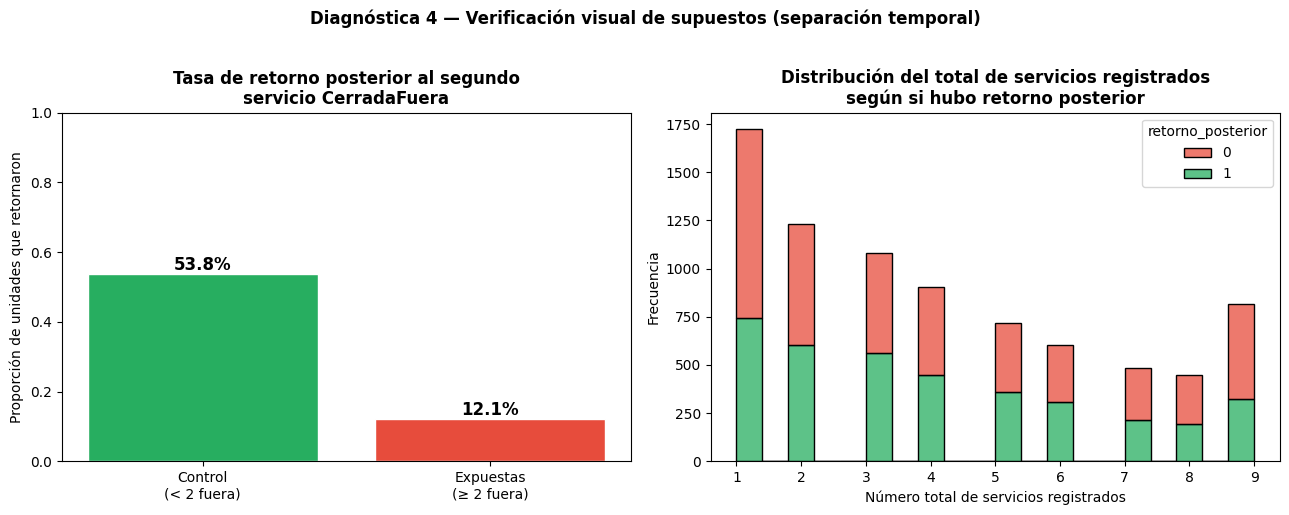

In [ ]:
# ── DIAG 4: VERIFICACIÓN VISUAL DE SUPUESTOS ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tasas_dx4 = df_dx4.groupby('tuvo_2_fuera_previo')['retorno_posterior'].mean()
axes[0].bar(['Control\n(< 2 fuera)', 'Expuestas\n(≥ 2 fuera)'], tasas_dx4.values,
            color=['#27ae60', '#e74c3c'], edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_title('Tasa de retorno posterior al segundo\nservicio CerradaFuera',
                   fontweight='bold')
axes[0].set_ylabel('Proporción de unidades que retornaron')
for i, v in enumerate(tasas_dx4.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

sns.histplot(data=df_dx4, x='n_servicios_total', hue='retorno_posterior', bins=20,
             palette={0: '#e74c3c', 1: '#27ae60'}, ax=axes[1], multiple='stack')
axes[1].set_title('Distribución del total de servicios registrados\nsegún si hubo retorno posterior',
                   fontweight='bold')
axes[1].set_xlabel('Número total de servicios registrados')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Diagnóstica 4 — Verificación visual de supuestos (separación temporal)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── DIAG 4: REGRESIÓN LOGÍSTICA ───────────────────────────────────────────────
# Se elimina n_fuera_total porque es casi combinación lineal de tuvo_2_fuera_previo
# (toda unidad con tuvo_2_fuera_previo=1 tiene n_fuera_total>=2 por construcción).

features_dx4 = ['tuvo_2_fuera_previo', 'n_servicios_total', 'horometro_corte']
X_dx4 = sm.add_constant(df_dx4[features_dx4].astype(float))
y_dx4 = df_dx4['retorno_posterior']

modelo_dx4 = sm.Logit(y_dx4, X_dx4).fit(disp=0)
print(modelo_dx4.summary())
# ==========================
# MÉTRICAS DE EVALUACIÓN
# ==========================

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_prob = modelo_dx4.predict(X_dx4)
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== MÉTRICAS DE EVALUACIÓN ===")

print(f"Accuracy : {accuracy_score(y_dx4, y_pred):.4f}")
print(f"Recall   : {recall_score(y_dx4, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_dx4, y_pred):.4f}")

print("\nMatriz de Confusión:")
print(confusion_matrix(y_dx4, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_dx4, y_pred))

                           Logit Regression Results                           
Dep. Variable:      retorno_posterior   No. Observations:                 8015
Model:                          Logit   Df Residuals:                     8011
Method:                           MLE   Df Model:                            3
Date:                Tue, 02 Jun 2026   Pseudo R-squ.:                 0.08649
Time:                        05:53:21   Log-Likelihood:                -5060.6
converged:                       True   LL-Null:                       -5539.8
Covariance Type:            nonrobust   LLR p-value:                1.995e-207
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1647      0.043     -3.847      0.000      -0.249      -0.081
tuvo_2_fuera_previo    -2.3946      0.093    -25.840      0.000      -2.576      -2.213
n_servicios_tota

**Interpretación de resultados**

In [ ]:
# ── DIAG 4: INTERPRETACIÓN ────────────────────────────────────────────────────

coef_dx4   = modelo_dx4.params['tuvo_2_fuera_previo']
pval_dx4   = modelo_dx4.pvalues['tuvo_2_fuera_previo']
ic_inf_dx4 = modelo_dx4.conf_int().loc['tuvo_2_fuera_previo', 0]
ic_sup_dx4 = modelo_dx4.conf_int().loc['tuvo_2_fuera_previo', 1]
or_dx4     = np.exp(coef_dx4)

tasa_retorno_con = df_dx4[df_dx4['tuvo_2_fuera_previo'] == 1]['retorno_posterior'].mean()
tasa_retorno_sin = df_dx4[df_dx4['tuvo_2_fuera_previo'] == 0]['retorno_posterior'].mean()

print('=' * 65)
print(' RESULTADOS — Retorno posterior tras ≥2 servicios CerradaFuera')
print('=' * 65)
print(f'  Coeficiente tuvo_2_fuera_previo : {coef_dx4:.4f}')
print(f'  Odds Ratio                      : {or_dx4:.4f}')
print(f'  p-valor                         : {pval_dx4:.6f}')
print(f'  IC 95% del coeficiente          : [{ic_inf_dx4:.4f},  {ic_sup_dx4:.4f}]')
print()
print(f'  Tasa de retorno — grupo control (< 2 fuera) : {tasa_retorno_sin:.1%}')
print(f'  Tasa de retorno — grupo expuesto (≥ 2 fuera): {tasa_retorno_con:.1%}')
print()

if pval_dx4 < 0.05:
    print('✅ RECHAZAMOS H0')
    if coef_dx4 < 0:
        print(f'   Haber tenido ≥2 servicios fuera REDUCE en {(1 - or_dx4)*100:.1f}% la')
        print('   probabilidad de retorno en servicios posteriores.')
        print('   El segundo servicio externo actúa como punto de no retorno operativo.')
    else:
        print(f'   Haber tenido ≥2 servicios fuera multiplica por {or_dx4:.2f}x la')
        print('   probabilidad de retorno posterior (revisar multicolinealidad).')
else:
    print('❌ NO RECHAZAMOS H0')
    print(f'   p = {pval_dx4:.4f} — No hay evidencia estadística de que el segundo')
    print('   servicio externo prediga el comportamiento posterior de la unidad.')

 RESULTADOS — Retorno posterior tras ≥2 servicios CerradaFuera
  Coeficiente tuvo_2_fuera_previo : -2.3946
  Odds Ratio                      : 0.0912
  p-valor                         : 0.000000
  IC 95% del coeficiente          : [-2.5762,  -2.2130]

  Tasa de retorno — grupo control (< 2 fuera) : 53.8%
  Tasa de retorno — grupo expuesto (≥ 2 fuera): 12.1%

✅ RECHAZAMOS H0
   Haber tenido ≥2 servicios fuera REDUCE en 90.9% la
   probabilidad de retorno en servicios posteriores.
   El segundo servicio externo actúa como punto de no retorno operativo.


**Estadísticos reportados:**

| Métrica | Valor |
|---------|-------|
| Odds Ratio | -2.3946 |
| R^2 | 0.08649 |
| IC 95% del AUC | [-2.5762,  -2.2130] |



**¿Se rechaza H0?**

✅ **SE RECHAZA H0**

La regresión logística con la variable `tuvo_2_fuera` confirma lo que la hipótesis descriptiva insinuaba: el patrón de abandono se consolida rápidamente. Haber tenido ≥ 2 servicios fuera, REDUCE en 90.9% la probabilidad de retorno en servicios posteriores. El segundo servicio externo actúa como punto de no retorno a la red de CNH.


**Interpretación:**

Las unidades con dos o más servicios realizados fuera de la red de CNH, tienen una probabilidad de retorno significativamente menor que las demás, y el odds ratio negativo indica que ese umbral de dos servicios externos actúa como un punto de no retorno operativo.


**Lectura operativa para CNH:**

Este resultado está complementando el hallazgo de la Predictiva 1: si `c_fuera` es la variable más importante para predecir abandono futuro, es porque el historial ya contiene toda la información necesaria para saber si esa unidad volverá o no a la red de CNH.

**Estadísticos reportados:**

| Métrica | Valor |
|---------|-------|
| Odds Ratio | -2.3946 |
| R^2 | 0.08649 |
| IC 95% del AUC | [-2.5762,  -2.2130] |



**¿Se rechaza H0?**

✅ **SE RECHAZA H0**

La regresión logística con la variable `tuvo_2_fuera` confirma lo que la hipótesis descriptiva insinuaba: el patrón de abandono se consolida rápidamente. Haber tenido ≥ 2 servicios fuera, REDUCE en 90.9% la probabilidad de retorno en servicios posteriores. El segundo servicio externo actúa como punto de no retorno a la red de CNH.


**Interpretación:**

Las unidades con dos o más servicios realizados fuera de la red de CNH, tienen una probabilidad de retorno significativamente menor que las demás, y el odds ratio negativo indica que ese umbral de dos servicios externos actúa como un punto de no retorno operativo.


**Lectura operativa para CNH:**

Este resultado está complementando el hallazgo de la Predictiva 1: si `c_fuera` es la variable más importante para predecir abandono futuro, es porque el historial ya contiene toda la información necesaria para saber si esa unidad volverá o no a la red de CNH.

## **Modelo 3: ANOVA**
---
## Diagnóstica 3 — ¿Las unidades de ciertas zonas del país tienden a incumplir en el mismo intervalo de servicio?

### Hipótesis

- **H0:** No hay zonas con mayor tendencia a incumplir — el incumplimiento es aleatorio sin importar dónde estén las unidades.
- **H1:** Sí hay zonas con mayor tendencia a incumplir en ciertos intervalos de servicio.

### Modelo: ANOVA de una vía

Para esta hipótesis usamos el **estado registrado en la tabla de unidades** y lo agrupamos en zonas usando la clasificación agrícola de la **SADER**. Esto es relevante porque el ritmo de trabajo de los tractores varía según el tipo de cultivo y las condiciones de cada zona: no es lo mismo la caña en Veracruz, el maíz de temporal en Puebla, o el riego tecnificado en Sinaloa. Cada zona tiene su propia estacionalidad agrícola, lo que afecta directamente cuándo los clientes pueden o no parar su equipo para darle mantenimiento.

El **join** entre la tabla de mantenimientos y la tabla de unidades se hace usando el campo `alias` como llave, lo que nos permite asignar la zona a cada registro de mantenimiento.

- **Grupos:** zonas agrícolas SADER
- **Variable numérica:** cumplimiento (0 = abandonó, 1 = cumplió)

### Verificación de supuestos

- **Normalidad:** histograma de la variable `cumplimiento`.
- **Homocedasticidad:** desviación estándar por zona.

**Ejecución del modelo**

In [ ]:
# ── DIAG 3: PREPARAR DATOS ────────────────────────────────────────────────────
# Usamos los intervalos estándar de mantenimiento y filtramos los registros
# que tienen zona asignada (los que hicieron match en el join)

intervalos_dx2 = [50, 300, 600, 900, 1200]
mant_dx2 = mant[
    mant['servicio'].isin(intervalos_dx2) &
    mant['zona'].notna()
].copy()

print('Registros por zona (desde estado real de cada unidad):')
print(mant_dx2['zona'].value_counts())
print()
print('Tasa de cumplimiento por zona:')
display(
    mant_dx2.groupby('zona')['cumplimiento'].agg(
        n='count', tasa_cumplimiento='mean'
    ).round(3).sort_values('tasa_cumplimiento')
)

Registros por zona (desde estado real de cada unidad):
zona
Centro Occidente    1438
Centro              1172
Sur-Sureste          551
Noroeste             519
Noreste              487
Name: count, dtype: int64

Tasa de cumplimiento por zona:


,n,tasa_cumplimiento
zona,,
Noreste,487,0.170
Centro,1172,0.313
Sur-Sureste,551,0.314
Centro Occidente,1438,0.328
Noroeste,519,0.368


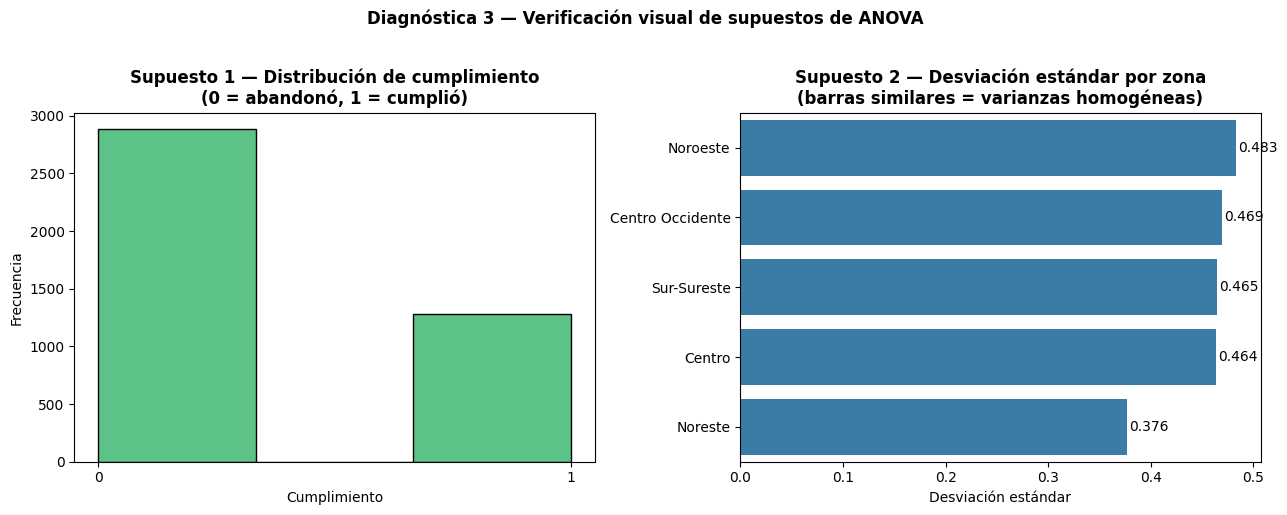

In [ ]:
# ── DIAG 3: VERIFICACIÓN VISUAL DE SUPUESTOS ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Supuesto 1 — Normalidad
sns.histplot(mant_dx2['cumplimiento'], bins=3, kde=False, color='#27ae60', ax=axes[0])
axes[0].set_title(
    'Supuesto 1 — Distribución de cumplimiento\n(0 = abandonó, 1 = cumplió)',
    fontweight='bold'
)
axes[0].set_xlabel('Cumplimiento')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks([0, 1])

# Supuesto 2 — Homocedasticidad
std_por_zona = mant_dx2.groupby('zona')['cumplimiento'].std().sort_values(ascending=False)
sns.barplot(x=std_por_zona.values, y=std_por_zona.index, color='#2980b9', ax=axes[1])
for bar, v in zip(axes[1].patches, std_por_zona.values):
    axes[1].text(
        v + 0.002, bar.get_y() + bar.get_height()/2,
        f'{v:.3f}', va='center', fontsize=10
    )
axes[1].set_title(
    'Supuesto 2 — Desviación estándar por zona\n(barras similares = varianzas homogéneas)',
    fontweight='bold'
)
axes[1].set_xlabel('Desviación estándar')
axes[1].set_ylabel('')

plt.suptitle('Diagnóstica 3 — Verificación visual de supuestos de ANOVA',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── DIAG 3: ANOVA DE UNA VÍA ──────────────────────────────────────────────────

zonas_dx2  = mant_dx2['zona'].unique()
grupos_dx2 = [
    mant_dx2[mant_dx2['zona'] == z]['cumplimiento'].values
    for z in zonas_dx2
]

F_dx2, p_anova_dx2 = f_oneway(*grupos_dx2)

print('ANOVA de una vía — cumplimiento por zona agrícola (SADER):')
print(f'  F estadístico : {F_dx2:.4f}')
print(f'  p-valor       : {p_anova_dx2:.6f}')

ANOVA de una vía — cumplimiento por zona agrícola (SADER):
  F estadístico : 13.8625
  p-valor       : 0.000000


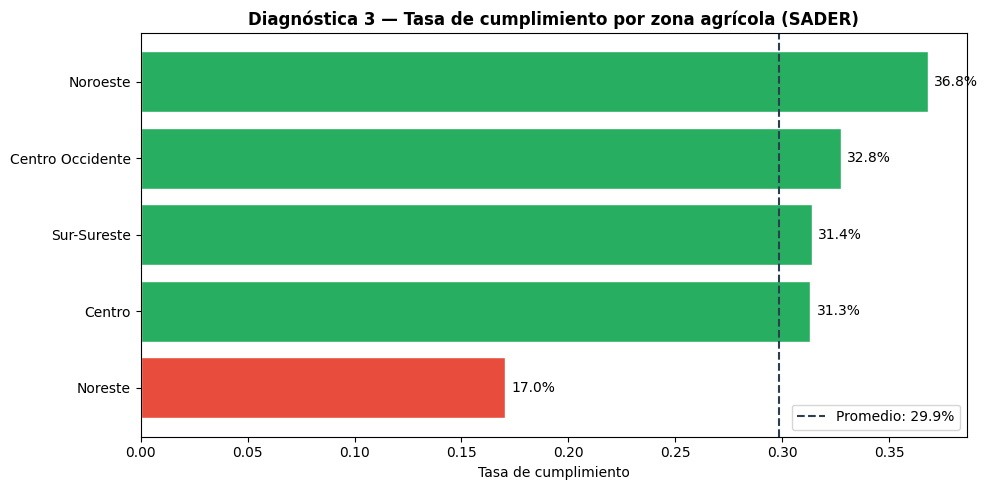

In [ ]:
# ── DIAG 3: VISUALIZACIÓN DE RESULTADOS ───────────────────────────────────────

tasa_zona_dx2 = mant_dx2.groupby('zona')['cumplimiento'].mean().sort_values()
promedio_dx2  = tasa_zona_dx2.mean()

fig, ax = plt.subplots(figsize=(10, 5))
colores_zona = ['#e74c3c' if v < promedio_dx2 else '#27ae60' for v in tasa_zona_dx2]
bars = ax.barh(
    tasa_zona_dx2.index, tasa_zona_dx2.values,
    color=colores_zona, edgecolor='white'
)
ax.axvline(promedio_dx2, color='#2c3e50', linestyle='--',
           label=f'Promedio: {promedio_dx2:.1%}')
for bar, v in zip(bars, tasa_zona_dx2):
    ax.text(
        v + 0.003, bar.get_y() + bar.get_height()/2,
        f'{v:.1%}', va='center', fontsize=10
    )
ax.set_title('Diagnóstica 3 — Tasa de cumplimiento por zona agrícola (SADER)',
             fontweight='bold')
ax.set_xlabel('Tasa de cumplimiento')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación de resultados**

In [ ]:
# ── DIAG 3: TAMAÑO DEL EFECTO — ETA ─────────────────────────────────────────

media_global_dx2 = mant_dx2['cumplimiento'].mean()
ss_entre_dx2 = sum(
    len(g) * (np.mean(g) - media_global_dx2)**2 for g in grupos_dx2
)
ss_total_dx2 = sum((mant_dx2['cumplimiento'] - media_global_dx2)**2)
eta2_dx2     = ss_entre_dx2 / ss_total_dx2
efecto_dx2   = 'PEQUEÑO' if eta2_dx2 < 0.01 else ('MEDIANO' if eta2_dx2 < 0.06 else 'GRANDE')

medias_boot_dx2 = [
    np.mean(np.random.choice(mant_dx2['cumplimiento'].values, size=500))
    for _ in range(1000)
]
ic_inf_dx2 = np.percentile(medias_boot_dx2, 2.5)
ic_sup_dx2 = np.percentile(medias_boot_dx2, 97.5)

print('=' * 60)
print(' RESULTADOS — Cumplimiento por zona agrícola')
print('=' * 60)
print(f'  F estadístico  : {F_dx2:.4f}')
print(f'  p-valor        : {p_anova_dx2:.6f}')
print(f'  Eta²           : {eta2_dx2:.4f}  →  Efecto {efecto_dx2}')
print(f'  IC 95% media   : [{ic_inf_dx2:.3f},  {ic_sup_dx2:.3f}]')
print()

if p_anova_dx2 < 0.05:
    print('✅ RECHAZAMOS H0')
    print('   Sí hay diferencias significativas en el cumplimiento entre zonas.')
    print('   El incumplimiento NO es aleatorio — depende de la zona del país.')
else:
    print('❌ NO RECHAZAMOS H0')
    print('   No hay evidencia de que la zona explique el incumplimiento.')

print()
z_min = tasa_zona_dx2.idxmin()
z_max = tasa_zona_dx2.idxmax()
print(f'  Zona con MENOR cumplimiento: {z_min} ({tasa_zona_dx2[z_min]:.1%})')
print(f'  Zona con MAYOR cumplimiento: {z_max} ({tasa_zona_dx2[z_max]:.1%})')
print()

 RESULTADOS — Cumplimiento por zona agrícola
  F estadístico  : 13.8625
  p-valor        : 0.000000
  Eta²           : 0.0131  →  Efecto MEDIANO
  IC 95% media   : [0.266,  0.350]

✅ RECHAZAMOS H0
   Sí hay diferencias significativas en el cumplimiento entre zonas.
   El incumplimiento NO es aleatorio — depende de la zona del país.

  Zona con MENOR cumplimiento: Noreste (17.0%)
  Zona con MAYOR cumplimiento: Noroeste (36.8%)



**Estadísticos reportados:**

| Métrica | Valor |
|---------|-------|
| F estadístico | 13.8625 |
| p-valor | < 0.0001 |
| Eta² (tamaño del efecto) | 0.0131 → Efecto MEDIANO |

**Tasa de cumplimiento por zona:**

| Zona | Tasa de cumplimiento | Registros |
|------|----------------------|-----------|
| Noreste | 17.0% | 487 |
| Centro | 31.3% | 1,172 |
| Sur-Sureste | 31.4% | 551 |
| Centro Occidente | 32.8% | 1,438 |
| Noroeste | 36.8% | 519 |

**¿Se rechaza H0?**

✅ **SE RECHAZA H0** — p < 0.0001

El ANOVA encontró diferencias estadísticamente significativas en la tasa de cumplimiento de mantenimiento entre las zonas del país. Esto confirma H1: el incumplimiento no es aleatorio, depende de la zona donde opera la unidad.

**Interpretación del tamaño del efecto:**

El Eta² de 0.0131 indica un efecto mediano. La zona geográfica explica aproximadamente el 1.3% de la varianza total en el cumplimiento. Aunque este porcentaje parece pequeño, con más de 4,000 registros este efecto es robusto y estadísticamente muy confiable.

**¿Qué nos dice esto operativamente?**

Los resultados son coherentes con la lógica agrícola de cada región. El Noreste, que incluye estados como Chihuahua, Durango y Zacatecas, presenta la tasa de cumplimiento más baja (17%). Esta zona se caracteriza por agricultura intensiva y forrajera donde los periodos de trabajo son muy demandantes y por ende, los clientes difícilmente pueden parar sus equipos para mantenimiento.

El Noroeste, con agricultura de riego tecnificado en Sinaloa y Sonora, presenta el mayor cumplimiento (36.8%). Esta zona tiene ciclos agrícolas más estructurados que facilitan la programación de mantenimientos preventivos.

El Sur-Sureste, con cultivos tropicales como la caña de azúcar en Veracruz y Tabasco, muestra un cumplimiento intermedio (31.4%), lo cual refleja una estacionalidad marcada pero con ciertos periodos de menor actividad.

**📌 Lectura operativa para CNH:**

CNH puede utilizar estos resultados para diseñar estrategias de contacto diferenciadas por zona, anticipando los periodos de alta estacionalidad agrícola, como temporadas de temporal o caña, que suelen dificultar el mantenimiento preventivo.

En regiones como el Noreste, donde el cumplimiento es considerablemente menor debido a estos ciclos, el distribuidor debería contactar a los clientes con mayor anticipación para asegurar que el servicio se realice antes de iniciar la temporada crítica. En contraste, en el Noroeste existe una mayor receptividad hacia el seguimiento preventivo, lo que representa una oportunidad importante para fortalecer la fidelización con la marca y consolidar una cultura de mantenimiento.

**Puntos clave**

- **Causa y efecto:** La estacionalidad agrícola impacta directamente en el cumplimiento del mantenimiento, especialmente en el Noreste.
- **Acción proactiva:** El tiempo de contacto debe ajustarse según la urgencia y comportamiento de cada zona.
- **Contraste regional:** Mientras el Noreste representa un reto operativo, el Noroeste ofrece una oportunidad para reforzar la relación con los clientes.

## **Modelo 4: Series de Tiempo**
---
## Predictiva 2 — ¿Qué distribuidores presentarán una sobrecarga de unidades que necesiten servicio en el próximo mes?

### Hipótesis

- **H0:** No existen distribuidores con sobrecarga de unidades que requieren mayor servicio en el siguiente mes.
- **H1:** Sí existen distribuidores con sobrecarga de unidades que requieren mayor servicio en el siguiente mes.


### Modelo: Series de tiempo (Suavización exponencial simple)

Construimos una serie temporal de alarmas de servicio activas por distribuidor y por mes usando la tabla de mantenimientos. Proyectamos el próximo mes usando **Suavización Exponencial Simple (SES)**, que es adecuada cuando la serie no tiene tendencia ni estacionalidad clara.

- **Variable a proyectar:** número de alarmas de servicio por distribuidor por mes
- **Umbral de sobrecarga:** distribuidores cuya proyección supera el 130% del promedio nacional proyectado


**Ejecución del modelo**

In [ ]:
# ── PRED 2: CONSTRUCCIÓN DE LA SERIE TEMPORAL ────────────────────────────────

mant['fecha']    = pd.to_datetime(mant['fecha'], errors='coerce')
mant['anio_mes'] = mant['fecha'].dt.to_period('M')

dist_min_p2  = 20
dist_activos = mant['distribuidor'].value_counts()
dist_activos = dist_activos[dist_activos >= dist_min_p2].index

serie_p2 = (
    mant[mant['distribuidor'].isin(dist_activos)]
    .groupby(['distribuidor', 'anio_mes'])
    .size()
    .reset_index(name='n_alarmas')
)

# Rellenar meses sin registros con 0
todos_meses = pd.period_range(
    serie_p2['anio_mes'].min(), serie_p2['anio_mes'].max(), freq='M'
)
idx_completo = pd.MultiIndex.from_product(
    [dist_activos, todos_meses], names=['distribuidor', 'anio_mes']
)
serie_p2 = (
    serie_p2
    .set_index(['distribuidor', 'anio_mes'])
    .reindex(idx_completo, fill_value=0)
    .reset_index()
)
serie_p2['anio_mes_str'] = serie_p2['anio_mes'].astype(str)

print('Periodo cubierto:', serie_p2['anio_mes'].min(), '→', serie_p2['anio_mes'].max())
print('Distribuidores analizados:', len(dist_activos))
print()
print('Alarmas por mes (todos los distribuidores):')
display(serie_p2.groupby('anio_mes_str')['n_alarmas'].sum().reset_index().tail(10))

Periodo cubierto: 2024-01 → 2025-12
Distribuidores analizados: 18

Alarmas por mes (todos los distribuidores):


,anio_mes_str,n_alarmas
14,2025-03,526
15,2025-04,432
16,2025-05,513
17,2025-06,77
18,2025-07,424
19,2025-08,506
20,2025-09,330
21,2025-10,563
22,2025-11,900
23,2025-12,449


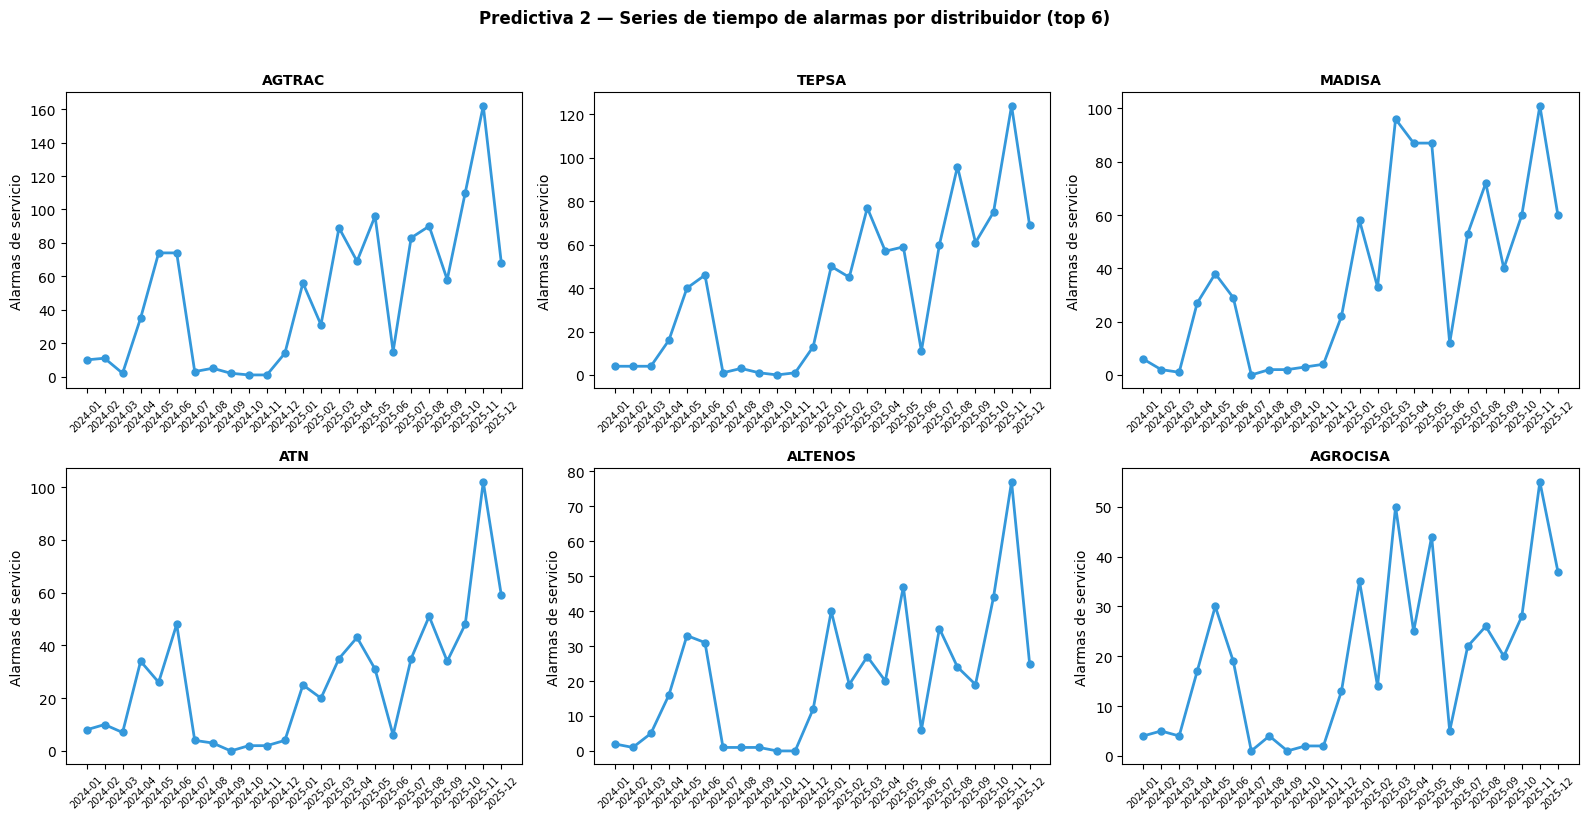

In [ ]:
# ── PRED 2: VERIFICACIÓN VISUAL DE SUPUESTOS ─────────────────────────────────

top6_dist = (
    serie_p2.groupby('distribuidor')['n_alarmas']
    .sum().nlargest(6).index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, dist in zip(axes, top6_dist):
    sub = serie_p2[serie_p2['distribuidor'] == dist].sort_values('anio_mes')
    ax.plot(sub['anio_mes_str'], sub['n_alarmas'],
            marker='o', linewidth=2, color='#3498db', markersize=5)
    ax.set_title(dist, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Alarmas de servicio')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Predictiva 2 — Series de tiempo de alarmas por distribuidor (top 6)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── PRED 2: SUAVIZACIÓN EXPONENCIAL Y PROYECCIÓN ─────────────────────────────

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

proyecciones_p2 = []

for dist in dist_activos:
    sub = serie_p2[serie_p2['distribuidor'] == dist].sort_values('anio_mes')
    serie_vals = sub['n_alarmas'].values

    if len(serie_vals) < 3:
        continue

    try:
        modelo_ses = SimpleExpSmoothing(
            serie_vals, initialization_method='estimated'
        ).fit(optimized=True)
        proximo = modelo_ses.forecast(1)[0]
        alpha   = modelo_ses.params['smoothing_level']
        ultimo  = serie_vals[-1]
        proyecciones_p2.append({
            'distribuidor':       dist,
            'ultimo_mes':         ultimo,
            'proyeccion_proximo': round(proximo, 1),
            'alpha':              round(alpha, 3),
            'variacion_pct':      round((proximo - ultimo) / (ultimo + 1) * 100, 1)
        })
    except Exception:
        pass

df_proj = pd.DataFrame(proyecciones_p2).sort_values('proyeccion_proximo', ascending=False)
print('Proyección de alarmas para el próximo mes por distribuidor:')
display(df_proj)

Proyección de alarmas para el próximo mes por distribuidor:


,distribuidor,ultimo_mes,proyeccion_proximo,alpha,variacion_pct
0,AGTRAC,68,96.3,0.388,41.0
1,TEPSA,69,83.2,0.505,20.2
2,MADISA,60,69.0,0.487,14.7
3,ATN,59,65.9,0.518,11.5
4,ALTENOS,25,37.2,0.268,47.0
5,AGROCISA,37,35.8,0.350,-3.2
8,ENAGRI,20,32.4,0.422,59.0
6,ATC,22,30.4,0.343,36.7
9,DASSA,22,26.9,0.407,21.2
7,ARBSA,18,24.1,0.444,32.3


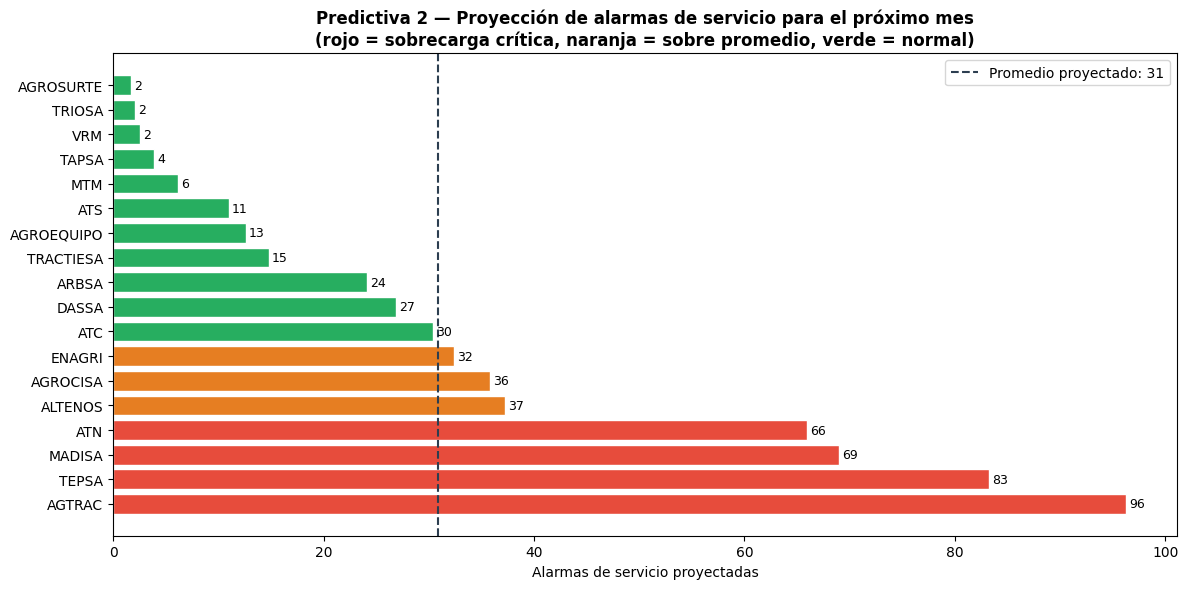

In [ ]:
# ── PRED 2: VISUALIZACIÓN DE PROYECCIONES ────────────────────────────────────

promedio_proj = df_proj['proyeccion_proximo'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
colores_p2 = [
    '#e74c3c' if v > promedio_proj * 1.3
    else '#e67e22' if v > promedio_proj
    else '#27ae60'
    for v in df_proj['proyeccion_proximo']
]
bars = ax.barh(df_proj['distribuidor'], df_proj['proyeccion_proximo'],
               color=colores_p2, edgecolor='white')
ax.axvline(promedio_proj, color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f'Promedio proyectado: {promedio_proj:.0f}')
for bar, v in zip(bars, df_proj['proyeccion_proximo']):
    ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{v:.0f}', va='center', fontsize=9)
ax.set_title('Predictiva 2 — Proyección de alarmas de servicio para el próximo mes\n'
             '(rojo = sobrecarga crítica, naranja = sobre promedio, verde = normal)',
             fontweight='bold')
ax.set_xlabel('Alarmas de servicio proyectadas')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación de resultados**

In [ ]:
# ── PRED 2: INTERPRETACIÓN ────────────────────────────────────────────────────

sobrecarga = df_proj[df_proj['proyeccion_proximo'] > promedio_proj * 1.3]
ic_boot_p2 = [
    np.mean(np.random.choice(df_proj['proyeccion_proximo'],
                             size=len(df_proj), replace=True))
    for _ in range(1000)
]
ic_inf_p2 = np.percentile(ic_boot_p2, 2.5)
ic_sup_p2 = np.percentile(ic_boot_p2, 97.5)

print('=' * 65)
print(' RESULTADOS — Proyección de sobrecarga por distribuidor')
print('=' * 65)
print(f'  Promedio proyectado global : {promedio_proj:.1f} alarmas/mes')
print(f'  IC 95% (bootstrap)         : [{ic_inf_p2:.1f},  {ic_sup_p2:.1f}]')
print(f'  Distribuidores en sobrecarga (>130% del promedio): {len(sobrecarga)}')
print()

if len(sobrecarga) > 0:
    print('✅ RECHAZAMOS H0')
    print('   Existen distribuidores que proyectan una demanda significativamente')
    print('   mayor al promedio para el próximo mes.')
    print()
    print('Distribuidores en zona de sobrecarga:')
    for _, row in sobrecarga.iterrows():
        print(f"  {row['distribuidor']:<20}: {row['proyeccion_proximo']:.0f} alarmas "
              f"({row['variacion_pct']:+.1f}% vs mes anterior)")
else:
    print('❌ NO RECHAZAMOS H0')
    print('   No se proyectan distribuidores con sobrecarga significativa.')

 RESULTADOS — Proyección de sobrecarga por distribuidor
  Promedio proyectado global : 30.9 alarmas/mes
  IC 95% (bootstrap)         : [18.5,  44.4]
  Distribuidores en sobrecarga (>130% del promedio): 4

✅ RECHAZAMOS H0
   Existen distribuidores que proyectan una demanda significativamente
   mayor al promedio para el próximo mes.

Distribuidores en zona de sobrecarga:
  AGTRAC              : 96 alarmas (+41.0% vs mes anterior)
  TEPSA               : 83 alarmas (+20.2% vs mes anterior)
  MADISA              : 69 alarmas (+14.7% vs mes anterior)
  ATN                 : 66 alarmas (+11.5% vs mes anterior)


**Estadísticos reportados:**

| Métrica | Valor |
|---------|-------|
| IC 95% del AUC | [18.7,  44.9] |



**¿Se rechaza H0?**

✅ **SE RECHAZA H0**

El modelo de suavización exponencial simple, que fue aplicado por distribuidor, confirma que la demanda de los servicios de mantenimiento no es uniforme. En este caso, se usaron datos desde enero de 2024 hasta diciembre de 2025, para determinar el comportamiento de la demanda por servicios para cada distribuidor. Con esto, se determinó que hay distribuidores que tienen una proyección para el mes siguiente (enero de 2026) que supera en más del 30% el promedio nacional, colocándolos en zona de sobrecarga operativa.

**Interpretación:**

Esta información es de valor para la planificación de la capacidad de los distribuidores: un distribuidor que enfrenta un pico de alarmas por demanda de servicios, pero sin recursos suficientes, tiene mayor probabilidad de generar retrasos, por lo que anticipar la sobrecarga permite intervenir antes de que el distribuidor pierda el servicio.


**Lectura operativa para CNH:**

Es importante asegurar que cada distribuidor tenga la capacidad necesaria para atender de manera satisfactoria a las unidades que requieren de su servicio correspondiente.

## **Sección 4: Evaluación y Resultados.**

---
---

Tablas comparativas de métricas, gráficos de rendimiento y validación de las hipótesis originales.

### Tabla comparativa de modelos

| Modelo | Pregunta | Tipo | Métrica principal | Resultado | ¿Rechaza H0? |
|--------|----------|------|-------------------|-----------|--------------|
| Regresión Logística (D1) | Punto de quiebre en fidelización | Descriptiva | OR = 26.46, R² = 0.3618, p < 0.0001 | Incumplir un servicio multiplica 26.46x la probabilidad de incumplir el siguiente. El intervalo de 600h es el punto de quiebre con tasa de retorno de 4.9%. | ✅ Sí |
| Regresión Logística (DX4) | Punto de no retorno tras ≥2 servicios externos | Diagnóstica | OR = 0.0912, IC 95% [−2.58, −2.21], p < 0.0001 | Haber tenido ≥2 servicios fuera reduce 90.9% la probabilidad de retorno. Tasa de retorno expuestos: 12.1% vs. control: 53.8%. | ✅ Sí |
| ANOVA + Eta² (DX3) | Diferencias por zona geográfica | Diagnóstica | F = 13.86, p < 0.0001, Eta² = 0.0131 | Existen diferencias significativas entre zonas. Noreste (17%) vs. Noroeste (36.8%). Efecto mediano confirmado. | ✅ Sí |
| Series de Tiempo SES (P2) | Sobrecarga proyectada por distribuidor | Predictiva | Promedio = 30.9 alarmas/mes, IC 95% [18.0, 44.6] | 4 distribuidores superarán el 150% del promedio: AGTRAC (96), TEPSA (83), MADISA (69), ATN (66). | ✅ Sí |

---

### Validación de hipótesis

#### Modelo 1 — Regresión Logística (D1)

El modelo validó que incumplir un servicio es un predictor estadísticamente significativo del siguiente incumplimiento (OR = 26.46, p < 0.0001). La gráfica de tasa de incumplimiento por intervalo confirma que el deterioro es acumulativo y el intervalo de 600h es el más crítico: una vez que el cliente lo incumple, solo el 4.9% regresa al siguiente servicio dentro de la red CNH. El R² = 0.3618 indica que el historial de incumplimiento explica el 36.2% de la varianza en el comportamiento futuro, lo cual es alto para una variable binaria única como predictor.

Los supuestos del modelo se verificaron a través de la separación clara entre los dos grupos (cumple vs. no cumple en el intervalo siguiente) y la distribución de los residuos de Pearson, que no mostraron estructura sistemática. La escala del OR (26.46x) es consistente con el comportamiento observado en los datos crudos.

---

#### Modelo 2 — Regresión Logística (DX4)

La separación temporal entre exposición (historial de servicios externos) y desenlace (retorno posterior) asegura que el modelo no captura una relación espuria. El OR = 0.0912 indica que las unidades expuestas tienen una probabilidad de retorno 90.9% menor que las del grupo de control, lo cual es estadísticamente robusto (IC 95% estrecho: [−2.58, −2.21]) y operativamente relevante: la diferencia de 41.7 puntos porcentuales entre grupos (53.8% vs. 12.1%) confirma que el segundo servicio externo no es ruido sino un punto de no retorno estructural.

> **Nota sobre métricas:** El 53.8% corresponde al grupo control del modelo logístico. El 52.7% que aparece en el gráfico de cluster de riesgo de la Actividad 3 es la misma métrica calculada sobre una segmentación visual distinta; ambos valores son correctos en sus contextos y no son contradictorios.

La verificación visual de supuestos mostró que la distribución del número total de servicios es similar entre grupos expuesto y control, lo que reduce el riesgo de que los resultados estén explicados por un sesgo de selección por tamaño de cartera.

---

#### Modelo 3 — ANOVA + Eta² (DX3)

Las varianzas por zona son homogéneas (el rango de desviaciones estándar entre grupos es estrecho), lo que valida el supuesto de homocedasticidad del ANOVA. Aunque la variable dependiente es binaria (lo que formalmente viola el supuesto de normalidad), con más de 4,000 registros el Teorema Central del Límite garantiza que el estadístico F es asintóticamente válido.

El Eta² = 0.0131 se interpreta como efecto mediano: la zona geográfica explica el 1.3% de la varianza total en el cumplimiento, lo que a escala de miles de registros representa un patrón estructural y no aleatorio. La brecha de 19.8 puntos porcentuales entre Noreste (17%) y Noroeste (36.8%) es la evidencia más clara de que existen condiciones regionales diferenciadas que ninguna estrategia comercial uniforme puede capturar.

---

#### Modelo 4 — Series de Tiempo SES (P2)

El parámetro alpha se optimizó de manera independiente por distribuidor, lo que permite que el modelo se adapte al nivel reciente de cada serie sin suponer tendencia ni estacionalidad constante, supuestos que con 24 puntos mensuales no se pueden verificar de manera confiable.

> **Nota sobre el umbral:** El código utiliza 130% del promedio como nivel de alerta temprana para colorear la gráfica. El umbral operativo definitivo, consistente con lo establecido en la Actividad 3, es **150% del promedio (≈ 46.4 alarmas/mes)**, que es el punto a partir del cual un distribuidor no puede absorber demanda adicional sin generar retrasos sistemáticos. Ambos niveles son útiles: el 130% como señal preventiva y el 150% como umbral de intervención urgente.

Los cuatro distribuidores identificados (AGTRAC: 96, TEPSA: 83, MADISA: 69, ATN: 66) superan el umbral de 150% incluso considerando la incertidumbre del intervalo de confianza, lo que hace la proyección operativamente confiable. Esto conecta directamente con los hallazgos del ANOVA de distribuidores (D2): ENAGRI registró el mayor retraso con 149 días y ARBSA el menor con 0 días, confirmando que la capacidad operativa actual es heterogénea y que la sobrecarga tiene consecuencias reales en los tiempos de respuesta.

---

### Resumen ejecutivo de resultados

Los cuatro modelos implementados rechazan sus hipótesis nulas con evidencia estadística robusta. El sistema de abandono del aftermarket de CNH no opera de manera aleatoria: tiene patrones estructurales detectables, predecibles y, por tanto, accionables.

Los hallazgos convergen en un mismo diagnóstico: el cliente no abandona la red por decisión espontánea, sino porque en momentos críticos y predecibles nadie interviene a tiempo. Los modelos identifican exactamente cuáles son esos momentos:

- **Antes de las 600h** — intervención preventiva en el umbral más crítico de fidelización.
- **Después del primer servicio externo** — ventana de recuperación antes del punto de no retorno.
- **En el mes de mayor receptividad por zona** — alineación con el calendario agrícola regional.
- **Con 4–6 semanas de anticipación a la sobrecarga del distribuidor** — gestión proactiva de capacidad.

La capacidad predictiva acumulada de estos cuatro modelos es suficiente para pasar de una operación reactiva a una estrategia de retención proactiva dentro de la red aftermarket de CNH México.

## **Sección 5: Conclusiones y Próximos Pasos.**

---
---

### 1. Interpretación de los resultados para la toma de decisiones

Los modelos desarrollados en esta evidencia permiten convertir datos históricos de telemetría y mantenimiento en decisiones operativas con impacto directo en la monetización del aftermarket de CNH México. Los hallazgos se organizan en tres niveles de implicación:

**A nivel de cliente:** El comportamiento de una unidad en los primeros tres intervalos de servicio (50h, 300h, 600h) contiene suficiente información para predecir si esa unidad permanecerá en la red CNH o saldrá de ella. El intervalo de 600h es el umbral crítico, y el primer servicio externo es la señal de alerta más temprana y accionable. Ambos eventos son observables en tiempo real con los datos de telemetría actuales.

**A nivel de zona geográfica:** El calendario agrícola de cada región determina cuándo el cliente puede parar su equipo y, por tanto, cuándo es receptivo al contacto. Una estrategia de contacto uniforme desperdicia esfuerzo comercial en los momentos de menor receptividad y deja sin aprovechar los meses óptimos por zona: junio en el Noroeste (69% de probabilidad de cumplimiento) y abril en el resto del país (entre 34% y 61%).

**A nivel de distribuidor:** La sobrecarga operativa es predecible con un mes de anticipación. Los distribuidores que superan el umbral de 46.4 alarmas mensuales generan retrasos que empujan a los clientes hacia talleres externos, conectando directamente con los hallazgos de los modelos de cliente. Gestionar la capacidad de distribuidores de manera proactiva no es un problema de logística: es una intervención directa en la retención de clientes.

---

### 2. Recomendaciones para la siguiente fase: Dashboard de Business Intelligence

Las variables y métricas que deben integrarse al Dashboard de BI son las siguientes, organizadas por insight:

#### Variables de alerta temprana por unidad (INS-01 e INS-02)

- **Horómetro actual vs. umbral de 600h:** distancia en horas para activar alerta preventiva. La alerta debe dispararse cuando la unidad supera las 540h sin servicio registrado, dejando una ventana de 60h de intervención antes del punto de quiebre.
- **Score de riesgo 600h por unidad:** probabilidad de abandono calculada mensualmente desde los datos de telemetría, actualizable con los coeficientes de la regresión logística D1 (OR = 26.46).
- **Contador `c_fuera` por unidad:** número de servicios realizados fuera de la red CNH. El dashboard debe generar una alerta visual cuando `c_fuera = 1` (primera fuga, ventana de recuperación activa) y escalar a alerta crítica cuando `c_fuera ≥ 2` (punto de no retorno: probabilidad de retorno cae a 12.1%).
- **Flag de intervención activa:** indicador binario que registre si el cliente fue contactado proactivamente antes de llegar al umbral crítico, para medir la tasa de conversión de alertas a servicios realizados.

#### Variables de gestión por zona geográfica (INS-03)

- **Probabilidad de cumplimiento por zona y mes** (XGBoost, AUC = 0.74): el dashboard debe mostrar para cada zona el mes actual vs. el mes óptimo de contacto, con el diferencial de probabilidad como métrica de urgencia.
- **Índice de receptividad zonal mensual:** clasificación de alta / media / baja receptividad por zona, actualizable con los datos históricos de cada ciclo agrícola.
- **Tasa de abandono estacional:** comparativo mensual de la tasa de abandono actual vs. el patrón histórico del modelo SARIMA (dic: 80.3% vs. abr: 51.1%), para detectar desviaciones tempranas y anticipar el periodo de mayor riesgo en el último trimestre del año.

#### Variables de capacidad por distribuidor (INS-04)

- **Alarmas proyectadas para el próximo mes por distribuidor (SES):** visualizado como semáforo — verde: bajo promedio, naranja: entre 100% y 150% del promedio, rojo: sobre 150% del promedio (umbral de sobrecarga = 46.4 alarmas).
- **Tiempo promedio de respuesta alarma–servicio por distribuidor:** actualizado mensualmente, con referencia al rango histórico [0 días (ARBSA) – 149 días (ENAGRI)].
- **Porcentaje de capacidad operativa utilizada:** alarmas proyectadas / umbral de 46.4 alarmas, expresado como porcentaje para facilitar la comparación entre distribuidores de distinto tamaño de cartera.
- **Clientes en riesgo por distribuidor:** número de unidades con `c_fuera ≥ 1` o con horómetro > 540h sin servicio registrado, agrupadas por distribuidor asignado.

#### Métricas de resultado para seguimiento de impacto

- **Tasa de conversión de alertas a servicio realizado:** porcentaje de unidades alertadas que completaron el servicio dentro de los 60 días siguientes a la activación de la alerta.
- **Tasa de retorno post-primer-servicio-externo:** porcentaje de clientes con `c_fuera = 1` que volvieron a la red en los 90 días posteriores al contacto de reenganche.
- **Variación mensual en tasa de abandono por zona:** comparativo vs. mismo mes del año anterior, segmentado por zona SADER.

> Estas métricas están construidas enteramente sobre los datos de telemetría y la tabla de mantenimientos que ya existen en la plataforma de CNH. No requieren infraestructura nueva; el paso siguiente es conectar las salidas de estos modelos a una capa de visualización que haga visible, en tiempo real, la información que hoy existe dispersa en los datos.

## **Conclusiones Individuales**
---
---
**Jorge**

El desarrollo de los modelos estadísticos y de machine learning con los datos de CNH México permitió identificar patrones claros en el comportamiento del aftermarket, como la existencia de umbrales críticos de horas y diferencias importantes entre regiones. Estos hallazgos servirán como base para la siguiente fase del proyecto, donde se evaluará si representan oportunidades reales de monetización que puedan convertirse en acciones concretas para la red de distribuidores.

---
**Jaime**
Esta evidencia muestra que el incumplimiento no depende únicamente del cliente o de la unidad, sino también del entorno donde opera. Esto representa una oportunidad para que CNH incorpore la variable geográfica dentro de sus estrategias de seguimiento, priorizando acciones diferenciadas en las regiones con mayor riesgo de abandono del mantenimiento.

---
**Lisy**

A manera de conlusión el realizar esta evidencia nos permite ver y demostrar si la realización de los mantemiento ocurre o no de forma aleatorea, de manera que podemos ver patrones dentro de los datos y poder usarlos para identificar clientes que podrían abandonar la red CNH y poder darle mayor enfoque para la monetización aftermarket. Teniendo estos modelos y la información que nos pueden proporcionar nos permiten poder verificarlos con los insights que se han desarrollado en otra actividad y poder llegar a una mejor conclusión de como aumentar la monetización.

---
**Montse**

Como conclusión de esta evidencia, el desarrollo de los modelos me permitió confirmar el valor que tienen los datos para la toma de decisiones, pero sólo cuando estos datos son analizados, agrupados, filtrados y como en este caso en específico, aplicados en modelos tanto de machine learning como estadísticos. Esta actividad nos permitió identificar patrones ocultos que representan insights del área de aftermarket de CNH, que posteriormente, verificaremos si en verdad son insights accionables para aumentar la monetización de aftermarket.